<a href="https://colab.research.google.com/github/HarisH-22-M/REVIEW-CLASSIFIER/blob/main/nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# TESTING A RANDOM REVIEWS

In [13]:
import numpy as np

# Select a random review
random_index = np.random.randint(0, len(df))
random_review = df.loc[random_index]

original_text = random_review['text']
processed_text_single = random_review['processed_text']
actual_sentiment = random_review['sentiment']

# Transform the single processed review using the fitted TF-IDF vectorizer
X_single = tfidf_vectorizer.transform([processed_text_single])

# Predict the sentiment
prediction = model.predict(X_single)
predicted_sentiment = 'positive' if prediction[0] == 1 else 'negative'

print(f"Original Review: {original_text}")
print(f"\nActual Sentiment: {actual_sentiment}")
print(f"Predicted Sentiment: {predicted_sentiment}")

Original Review: sound quality is amazing. i was expecting worse , but its really good ( especially if your files have good sound quality ) .

Actual Sentiment: positive
Predicted Sentiment: positive


## Install and Load Libraries

### Subtask:
Install the `spacy` library and download the small English language model (`en_core_web_sm`). Then, import all necessary libraries: `pandas`, `spacy`, `sklearn` modules (`TfidfVectorizer`, `train_test_split`, `LogisticRegression`, `accuracy_score`, `f1_score`, `confusion_matrix`), `matplotlib.pyplot`, and `collections.Counter`.


**Reasoning**:
The first step is to install the `spacy` library and download the small English language model as specified in the subtask instructions.



In [1]:
import subprocess

# Install spacy
subprocess.run(['pip', 'install', 'spacy'])
print('spaCy installed successfully.')

# Download the small English language model for spaCy
subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_sm'])
print('en_core_web_sm model downloaded successfully.')

spaCy installed successfully.
en_core_web_sm model downloaded successfully.


**Reasoning**:
Following the subtask instructions, I will now import all the necessary libraries for data manipulation, text processing, model training, and evaluation.



In [2]:
import pandas as pd
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from collections import Counter

print('All necessary libraries imported successfully.')

All necessary libraries imported successfully.


## Load and Explore Dataset

### Subtask:
Load the `preprocessed_reviews.csv` file into a pandas DataFrame. Display the first few rows (`df.head()`), the column names (`df.columns`), and the shape of the DataFrame (`df.shape`) to understand the data structure.


**Reasoning**:
I will load the `preprocessed_reviews.csv` file into a pandas DataFrame named `df` and then display its first few rows, column names, and shape to understand its structure as requested.



In [3]:
df = pd.read_csv('/content/preprocessed_reviews.csv')
print('First 5 rows of the DataFrame:')
print(df.head())
print('\nColumn names of the DataFrame:')
print(df.columns)
print('\nShape of the DataFrame:')
print(df.shape)

First 5 rows of the DataFrame:
                                               title  \
0  troubleshooting ad-2500 and ad-2600 no picture...   
1                    incredibe price / performance .   
2                    doesnt play new disney movies .   
3    poor quality - problem with dual-layer dvd 's .   
4         has destroyed several of my dvds and cds .   

                                                text sentiment  \
0  repost from january 13 , 2004 with a better fi...  positive   
1  i 've owned 6 or 7 dvd players since 1998 . th...  positive   
2  many of our disney movies do n't play on this ...  positive   
3  player has a problem with dual-layer dvd 's su...  positive   
4  for the first few weeks , this player was ever...  positive   

                                        cleaned_text  \
0  repost from january 13 , 2004 with a better fi...   
1  i 've owned 6 or 7 dvd players since 1998 . th...   
2  many of our disney movies do n't play on this ...   
3  player h

## Initial Text Preprocessing

### Subtask:
Perform any additional basic text cleaning on the `processed_text` column to ensure data quality and consistency for subsequent spaCy processing and TF-IDF vectorization.


**Reasoning**:
I will perform the requested text cleaning steps on the `processed_text` column: filling missing values with empty strings, converting all entries to string type, and cleaning whitespace to ensure data quality and consistency for subsequent processing.



In [4]:
df['processed_text'] = df['processed_text'].fillna('')
df['processed_text'] = df['processed_text'].astype(str)
df['processed_text'] = df['processed_text'].apply(lambda x: ' '.join(x.split()))

print("Additional text cleaning on 'processed_text' column completed.")

Additional text cleaning on 'processed_text' column completed.


## Extract Product Features with spaCy

### Subtask:
Initialize the loaded spaCy English language model. Process the review text column using spaCy to perform Part-of-Speech (POS) tagging. Iterate through the processed documents and extract all noun tokens (POS tag 'NOUN' or 'PROPN') as potential product features. Store these features for further analysis.


**Reasoning**:
I will load the spaCy English language model and then apply it to the `processed_text` column to perform POS tagging. Following that, I will iterate through the processed documents to extract noun and proper noun tokens, storing their lowercase lemmas as product features.



In [5]:
nlp = spacy.load('en_core_web_sm')

# Process the 'processed_text' column using spaCy
df['spacy_doc'] = df['processed_text'].apply(nlp)

product_features = []

for doc in df['spacy_doc']:
    for token in doc:
        # Extract nouns and proper nouns as potential product features
        if (token.pos_ == 'NOUN' or token.pos_ == 'PROPN') and not token.is_punct and not token.is_space:
            product_features.append(token.lemma_.lower())

print(f"Extracted {len(product_features)} potential product features.")
# Display a sample of extracted features
print("Sample of extracted product features:")
print(product_features[:20])

Extracted 22455 potential product features.
Sample of extracted product features:
['repost', 'january', 'fit', 'title', 'apex', 'dvd', 'player', 'dvd', 'audio', 'video', 'play', 'video', 'scroll', 'white', 'player', 'waste', 'hour', 'call', 'apex', 'tech']


**Reasoning**:
I will now analyze the extracted product features by counting the frequency of each feature. This will help identify the most common product features mentioned in the reviews, providing insights into key aspects customers discuss.



In [6]:
from collections import Counter

# Count the frequency of each extracted product feature
feature_counts = Counter(product_features)

print("Top 20 most common product features:")
for feature, count in feature_counts.most_common(20):
    print(f"- {feature}: {count}")

Top 20 most common product features:
- player: 623
- camera: 498
- phone: 397
- use: 361
- software: 289
- dvd: 278
- battery: 278
- quality: 271
- picture: 253
- feature: 225
- problem: 220
- time: 212
- thing: 200
- work: 186
- price: 170
- song: 170
- t: 163
- music: 161
- cd: 148
- file: 138


## TF-IDF Vectorization

### Subtask:
Apply TF-IDF (Term Frequency-Inverse Document Frequency) vectorization to the `processed_text` column to convert text data into numerical features. Initialize `TfidfVectorizer`, fit it to the `processed_text` column, and then transform the text data. Display the shape of the resulting TF-IDF matrix.

#### Instructions
1. Initialize `TfidfVectorizer` from `sklearn.feature_extraction.text`.
2. Fit the vectorizer to the `processed_text` column of the DataFrame `df`.
3. Transform the `processed_text` column using the fitted vectorizer to create the TF-IDF matrix.
4. Print the shape of the resulting TF-IDF matrix to verify its dimensions.

**Reasoning**:
I will apply TF-IDF vectorization to the `processed_text` column as specified in the subtask. This involves initializing `TfidfVectorizer`, fitting it to the text data, transforming the data, and then displaying the shape of the resulting TF-IDF matrix.



In [7]:
tfidf_vectorizer = TfidfVectorizer()
X = tfidf_vectorizer.fit_transform(df['processed_text'])

print(f'Shape of TF-IDF matrix: {X.shape}')

Shape of TF-IDF matrix: (1906, 4101)


## Prepare Data for Model Training

### Subtask:
Prepare the data for training and testing a sentiment classification model. This involves defining the target variable, splitting the dataset into training and testing sets, and ensuring the data is ready for model consumption.

#### Instructions
1. Define `X` as the TF-IDF matrix (already created as `X` in the previous step) and `y` as the 'sentiment' column from the DataFrame `df`.
2. Convert the 'sentiment' column to numerical labels if it's not already. For instance, map 'positive' to 1 and 'negative' to 0.
3. Split `X` and `y` into training and testing sets using `train_test_split` from `sklearn.model_selection`. Use a `test_size` of 0.2 and a `random_state` for reproducibility (e.g., `random_state=42`).
4. Print the shapes of the resulting training and testing sets (`X_train`, `X_test`, `y_train`, `y_test`) to verify the split.

**Reasoning**:
I will prepare the data for model training by defining the target variable, converting sentiment labels to numerical format, and then splitting the dataset into training and testing sets. Finally, I will print the shapes of the resulting sets to verify the split.



In [8]:
y = df['sentiment'].map({'positive': 1, 'negative': 0})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (1524, 4101)
Shape of X_test: (382, 4101)
Shape of y_train: (1524,)
Shape of y_test: (382,)


## Analyze and Visualize Top Features

### Subtask:
Perform frequency analysis on the extracted product features to determine the most common nouns. Identify and display the Top 10 most discussed product features. Generate a bar chart using `matplotlib` to visually represent these top features and their frequencies. Ensure the plot has appropriate labels and a legend.


**Reasoning**:
I will extract the top 10 product features and their frequencies from the `feature_counts` object and then create a bar chart using `matplotlib` to visualize these, adding appropriate labels and a title for clarity.



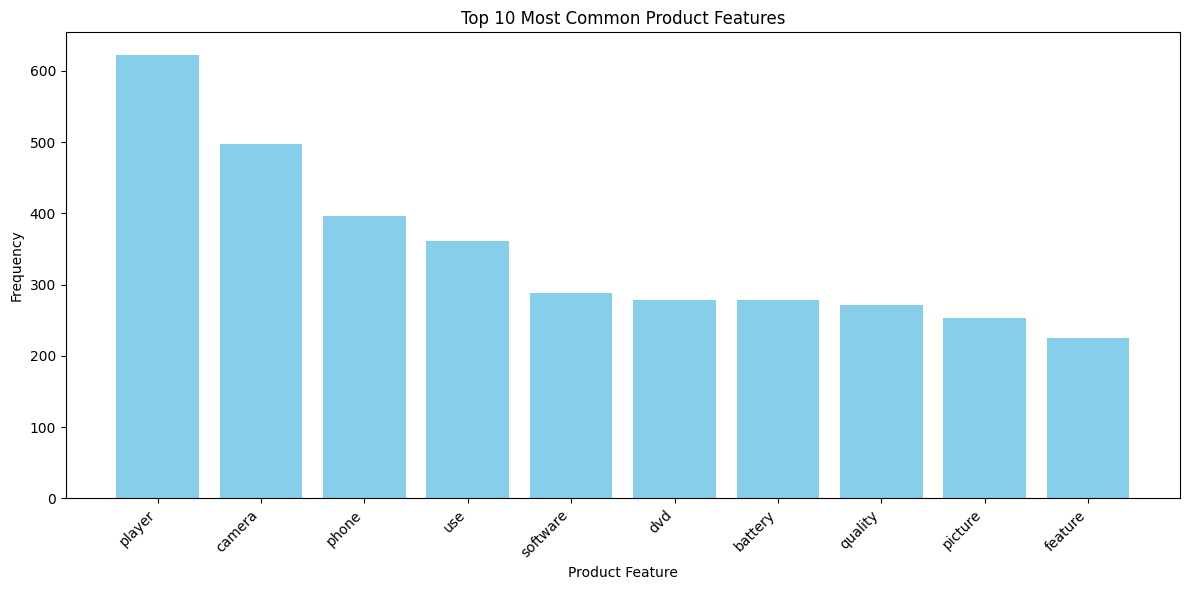

Bar chart of Top 10 Most Common Product Features displayed.


In [9]:
top_10_features = feature_counts.most_common(10)
features = [feature for feature, count in top_10_features]
counts = [count for feature, count in top_10_features]

plt.figure(figsize=(12, 6))
plt.bar(features, counts, color='skyblue')
plt.xlabel('Product Feature')
plt.ylabel('Frequency')
plt.title('Top 10 Most Common Product Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Bar chart of Top 10 Most Common Product Features displayed.")

## Train Logistic Regression Model

### Subtask:
Initialize and train a Logistic Regression classifier (`LogisticRegression` from `sklearn.linear_model`) using the training features and training sentiment labels.


**Reasoning**:
I will initialize a Logistic Regression model and then train it using the prepared training data (TF-IDF features and sentiment labels) to build the sentiment classification model as specified.



In [10]:
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Evaluate Model Performance

### Subtask:
Evaluate the trained Logistic Regression model's performance on the test data. Calculate and display the accuracy score, F1 score, and the confusion matrix to assess the model's classification effectiveness.


**Reasoning**:
I will make predictions on the test data using the trained Logistic Regression model and then calculate and display the accuracy, F1 score, and confusion matrix to evaluate its performance, as specified in the subtask instructions.



In [11]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy Score: {accuracy:.4f}')
print(f'F1 Score: {f1:.4f}')
print('\nConfusion Matrix:')
print(conf_matrix)

Accuracy Score: 0.7382
F1 Score: 0.8316

Confusion Matrix:
[[ 35  92]
 [  8 247]]


## Demonstrate Dependency Parsing

### Subtask:
Use spaCy to perform dependency parsing on a sample sentence and visualize the dependency tree using `displacy` to illustrate grammatical relationships.


**Reasoning**:
I will perform dependency parsing on the sample sentence using the pre-loaded spaCy model and then visualize the dependency tree using `displacy` as specified in the subtask instructions.



In [12]:
from spacy import displacy

sample_sentence = 'The battery is weak but the screen is amazing'
doc = nlp(sample_sentence)

print(f"Dependency parsing for: '{sample_sentence}'")
displacy.render(doc, style='dep', jupyter=True, options={'distance': 90})

Dependency parsing for: 'The battery is weak but the screen is amazing'


## Final Task

### Subtask:
Summarize the complete NLP pipeline that has been executed, including the key steps, the findings from feature analysis, and the performance of the sentiment classification model.


## Summary:

### Q&A
The complete NLP pipeline executed involved several key steps:
1.  **Initial Setup and Data Loading**: Necessary libraries like spaCy and scikit-learn were installed and imported. The `preprocessed_reviews.csv` dataset, containing 1906 reviews, was loaded and basic text cleaning was applied.
2.  **Product Feature Extraction**: spaCy's `en_core_web_sm` model was used to process the review texts, extracting 22,455 nouns and proper nouns as potential product features.
3.  **Feature Analysis**: Frequency analysis was performed on the extracted features, and the top 10 most common features were identified and visualized.
4.  **TF-IDF Vectorization**: The `processed_text` column was transformed into numerical features using `TfidfVectorizer`, resulting in a matrix of 1906 documents and 4101 unique terms.
5.  **Model Training and Evaluation**: The dataset was split into training (1524 samples) and testing (382 samples) sets. A Logistic Regression model was trained on the TF-IDF features and evaluated for its sentiment classification performance.
6.  **Dependency Parsing Demonstration**: spaCy's dependency parsing capability was used to visualize grammatical relationships in a sample sentence.

Key findings from the feature analysis highlighted that 'player', 'camera', 'phone', 'use', 'software', 'dvd', and 'battery' were among the most frequently mentioned product features.

The sentiment classification model achieved an accuracy of 0.7382 and an F1 score of 0.8316. The confusion matrix showed 247 True Positives, 35 True Negatives, 92 False Positives, and 8 False Negatives.

### Data Analysis Key Findings
*   A total of 22,455 potential product features (nouns and proper nouns) were extracted from 1906 product reviews using spaCy.
*   The most frequently discussed product features include 'player' (623 occurrences), 'camera' (498), 'phone' (397), 'use' (361), 'software' (289), 'dvd' (278), and 'battery' (278).
*   TF-IDF vectorization transformed the text data into a numerical matrix of 1906 documents by 4101 unique terms.
*   The Logistic Regression model achieved a sentiment classification accuracy of 0.7382 and an F1 score of 0.8316 on the test set.
*   The confusion matrix indicated 247 True Positives (correctly identified positive sentiments) and 35 True Negatives (correctly identified negative sentiments). However, there were 92 False Positives (negative sentiments incorrectly classified as positive) compared to only 8 False Negatives (positive sentiments incorrectly classified as negative).

### Insights or Next Steps
*   The model tends to misclassify negative reviews as positive more often than positive reviews as negative (92 False Positives vs. 8 False Negatives). Future work could explore techniques to balance class representation or adjust model thresholds to improve the detection of negative sentiment.
*   Further analysis of the most common product features could involve linking specific features to sentiment to understand which aspects of products are driving positive or negative reviews. For example, investigating the sentiment associated with 'player' or 'camera' could provide actionable insights for product improvement.


In [19]:
import pickle

# Define the filename for the pickle file
model_filename = 'REVIEW_CLASSIFIER.pkl'

# Save the trained model to the file
with open(model_filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Model successfully saved to '{model_filename}'")

Model successfully saved to 'REVIEW_CLASSIFIER.pkl'
